# IMC Pancreas data visualizations

- Cell type composition

In [5]:
import sys
sys.path.append('..')

from utils import load_paths

In [6]:
BASE_DIR_REPO, BASE_DIR_PROJECT = load_paths()
DATA = "damond19"

HPC cluster


In [7]:
import sys
from pathlib import Path
import os

# Add project root to path (go up 2 levels from notebook location)
project_root = Path(f'{BASE_DIR_REPO}/InterScale_reproducibility')
print(project_root)
sys.path.insert(0, str(project_root))

/home/icb/francesca.drummer/1-Projects/InterScale_reproducibility


In [15]:
import yaml
import matplotlib.pyplot as plt
import os

with open(os.path.join(BASE_DIR_REPO, "InterScale_reproducibility/figures/config.yml"), "r") as f:
    config = yaml.safe_load(f)

PALETTE = config["palettes"]["continuous"]
CELL_TYPE_COLORS = config["palettes"][DATA]

In [9]:
import scanpy as sc
import squidpy as sq

/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Imp

## Figure setting

In [10]:
import yaml
import matplotlib.pyplot as plt

with open(os.path.join(BASE_DIR_REPO, "InterScale_reproducibility/figures/config.yml"), "r") as f:
    config = yaml.safe_load(f)

PALETTE = config["palettes"]["continuous"]
CELL_TYPE_COLORS = config["palettes"]["melton25"]

## Load data

In [11]:
adata = sc.read_h5ad(os.path.join(BASE_DIR_PROJECT, 'data', 'imc_pancreas_pp.h5ad'))
adata

AnnData object with n_obs × n_vars = 1776974 × 38
    obs: 'ImageNumber', 'ObjectNumber', 'Location_Center_X', 'Location_Center_Y', 'Number_Object_Number', 'image_name', 'id', 'CellCat', 'CellType', 'case', 'slide', 'part', 'group', 'stage', 'duration', 'Aab status', 'Age', 'Gender', 'Ethnicity', 'BMI', 'sliding_window_assignment', 'ImageNumber_int', 'split', '_scvi_batch', '_scvi_labels', 'scvi'
    uns: 'CellCat_colors', 'CellType_colors', '_scvi_manager_uuid', '_scvi_uuid', 'morphology', 'scvi'
    obsm: 'X_scVI', 'spatial'
    layers: 'MeanIntensity', 'MedianIntensity', 'pct-norm-99'
    obsp: 'scvi_connectivities', 'scvi_distances', 'spatial_connectivities', 'spatial_distances'

In [14]:
adata.obs['CellType']

0          acinar
1          acinar
2          acinar
3          acinar
4          acinar
            ...  
1776969    ductal
1776970    acinar
1776971    acinar
1776972    acinar
1776973    acinar
Name: CellType, Length: 1776974, dtype: category
Categories (16, object): ['B', 'Tc', 'Th', 'acinar', ..., 'neutrophil', 'otherimmune', 'stromal', 'unknown']

## Cell type composition

/localscratch/francesca.drummer/ipykernel_37142/3948730367.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = adata.obs.groupby(['stage', 'CellType']).size().unstack(fill_value=0)


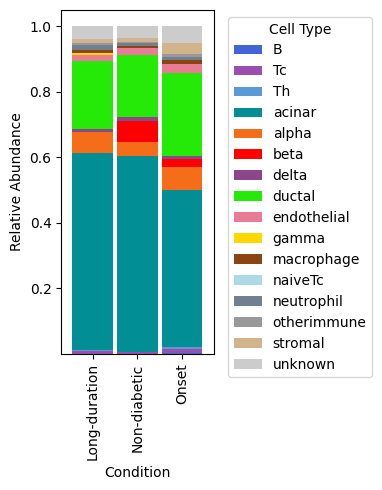

In [17]:
# Step 1: Group observations by 'condition' and count each 'CellTypes_max' entry
counts = adata.obs.groupby(['stage', 'CellType']).size().unstack(fill_value=0)

# Step 2: Calculate relative abundance (proportion) by normalizing counts within each condition
relative_abundance = counts.div(counts.sum(axis=1), axis=0)

#colors = adata.uns['Niche_label_colors']

# Step 3: Plot stacked bar plot
relative_abundance.plot(kind='bar', stacked=True, color=CELL_TYPE_COLORS, figsize=(4, 5),width=0.9)

# Add labels and title
plt.xlabel('Condition')
plt.ylabel('Relative Abundance')
#plt.title('Relative Abundance of Cell Types by Condition')
plt.legend(title='Cell Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f"{project_root}/figures/{DATA}/data_visualization/cell_type_relative_abundance_per_condition.png", format="png", bbox_inches="tight", dpi=1200)
plt.show()

## Pseudobulking

In [18]:
pdata = dc.pp.pseudobulk(
    adata=adata,
    sample_col="id",
    groups_col="case",
    mode="sum",
)

NameError: name 'dc' is not defined